In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
DATA_PATH = "clothing_recommendations.xlsx"
MODEL_PATH = "similarity_model.joblib"


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving clothing_recommendations.csv to clothing_recommendations.csv


In [ ]:

import os
import requests # Import the requests library

# 1. Load data + rebuild a full item catalog

csv_filename = "clothing_recommendations.csv"
excel_filename = "clothing_recommendations.xlsx"
DATA_PATH = excel_filename # Ensure DATA_PATH is consistent

# Ensure the source CSV file is available.
if not os.path.exists(csv_filename):
    print(f"Downloading '{csv_filename}'...")
    url = "https://raw.githubusercontent.com/google/ai-for-social-good/main/clothing_recommendations.csv"
    try:
        response = requests.get(url)
        response.raise_for_status() # Raise an exception for HTTP errors
        with open(csv_filename, 'wb') as f:
            f.write(response.content)
        print("Download complete.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading '{csv_filename}': {e}")
        # Exit or raise to prevent further errors if download failed
        raise

# Check if the expected Excel file exists; if not, and the CSV exists, rename it.
if not os.path.exists(DATA_PATH) and os.path.exists(csv_filename):
    print(f"Renaming '{csv_filename}' to '{DATA_PATH}'...")
    os.rename(csv_filename, DATA_PATH) # Use os.rename instead of !mv for consistency and portability
    print("Rename complete.")

df = pd.read_excel(DATA_PATH)

In [ ]:
# -----------------------------
# Dataset Verification
# -----------------------------
print("=" * 50)
print("DATASET VERIFICATION")
print("=" * 50)

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

print("\nSummary Statistics:")
display(df.describe(include='all'))

print("\nUnique Categories:")
print(df["source_category"].unique())

print("\nVerification Completed Successfully.")

DATASET VERIFICATION

Dataset Shape:
(250, 9)

Missing Values:
source_id             0
source_name           0
source_category       0
rank                  0
recommended_id        0
recommended_name      0
recommended_price     0
recommended_rating    0
similarity_score      0
dtype: int64

Duplicate Rows:
0

Data Types:
source_id              object
source_name            object
source_category        object
rank                    int64
recommended_id         object
recommended_name       object
recommended_price       int64
recommended_rating    float64
similarity_score      float64
dtype: object

Summary Statistics:


,source_id,source_name,source_category,rank,recommended_id,recommended_name,recommended_price,recommended_rating,similarity_score
count,250,250,250,250.000000,250,250,250.000000,250.000000,250.000000
unique,50,50,5,NaN,45,45,NaN,NaN,NaN
top,C001,Vintage Floral Crop Top,Tops,NaN,C018,Asymmetric Wrap Skirt,NaN,NaN,NaN
freq,5,5,50,NaN,13,13,NaN,NaN,NaN
mean,NaN,NaN,NaN,3.000000,NaN,NaN,738.800000,4.142000,0.952426
std,NaN,NaN,NaN,1.417051,NaN,NaN,480.411637,0.439098,0.038148
min,NaN,NaN,NaN,1.000000,NaN,NaN,120.000000,3.200000,0.755500
25%,NaN,NaN,NaN,2.000000,NaN,NaN,420.000000,3.900000,0.945125
50%,NaN,NaN,NaN,3.000000,NaN,NaN,680.000000,4.200000,0.961100
75%,NaN,NaN,NaN,4.000000,NaN,NaN,900.000000,4.600000,0.980350



Unique Categories:
['Tops' 'Bottoms' 'Dresses' 'Outerwear' 'Accessories']

Verification Completed Successfully.


In [ ]:
print(df.columns)

Index(['source_id', 'source_name', 'source_category', 'rank', 'recommended_id',
       'recommended_name', 'recommended_price', 'recommended_rating',
       'similarity_score'],
      dtype='object')


In [ ]:
display(df.head())

,source_id,source_name,source_category,rank,recommended_id,recommended_name,recommended_price,recommended_rating,similarity_score
0,C001,Vintage Floral Crop Top,Tops,1,C009,Floral Smocked Blouse,480,3.3,0.9914
1,C001,Vintage Floral Crop Top,Tops,2,C008,90s Polo Shirt,900,3.7,0.9859
2,C001,Vintage Floral Crop Top,Tops,3,C034,Cozy Knit Cardigan,950,4.2,0.9858
3,C001,Vintage Floral Crop Top,Tops,4,C032,Oversized Blazer,1200,3.9,0.9848
4,C001,Vintage Floral Crop Top,Tops,5,C005,Linen Button Down Shirt,650,4.5,0.9838


In [ ]:
# Every item shows up as a "recommended_id" somewhere (with price/rating/name),
# and most also show up as a "source_id" (with category). Merge both views
# into one clean catalog: id -> name, category, price, rating.
catalog = {}

for _, r in df.iterrows():
    catalog.setdefault(r.source_id, {"name": r.source_name, "category": r.source_category})


for _, r in df.iterrows():
    entry = catalog.setdefault(r.recommended_id, {})
    entry.setdefault("name", r.recommended_name)
    entry["price"] = r.recommended_price
    entry["rating"] = r.recommended_rating
    # category, if we don't already know it, gets filled in later (source rows only)

catalog_df = pd.DataFrame.from_dict(catalog, orient="index")
catalog_df.index.name = "item_id"

In [ ]:
# A few items only ever appear as "recommended" and never as "source", so they
# have no category and/or price/rating from the other side. Impute sensibly:
catalog_df["category"] = catalog_df["category"].fillna("Unknown")
catalog_df["price"] = catalog_df.groupby("category")["price"].transform(
    lambda s: s.fillna(s.mean())
)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "regressor__n_estimators":[100,200,300],
    "regressor__learning_rate":[0.01,0.05,0.1],
    "regressor__max_depth":[2,3,4]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Score:")
print(grid_search.best_score_)

best_model = grid_search.best_estimator_

Best Parameters:
{'regressor__learning_rate': 0.05, 'regressor__max_depth': 4, 'regressor__n_estimators': 300}
Best CV Score:
-0.019394812824423745


In [ ]:
catalog_df["rating"] = catalog_df.groupby("category")["rating"].transform(
    lambda s: s.fillna(s.mean())
)
catalog_df["price"] = catalog_df["price"].fillna(catalog_df["price"].mean())
catalog_df["rating"] = catalog_df["rating"].fillna(catalog_df["rating"].mean())


print(f"Rebuilt catalog with {len(catalog_df)} unique items.")

Rebuilt catalog with 50 unique items.


In [ ]:
# 2. Build pairwise training features from the original rows
# ---------------------------------------------------------------------------
def make_features(row_df, catalog_df):
    feats = row_df.copy()

    src = catalog_df.loc[feats["source_id"]].reset_index(drop=True)
    rec = catalog_df.loc[feats["recommended_id"]].reset_index(drop=True)

    feats["source_price"] = src["price"].values
    feats["source_rating"] = src["rating"].values
    feats["recommended_category"] = rec["category"].values
    feats["same_category"] = (
        feats["source_category"] == feats["recommended_category"]
    ).astype(int)
    feats["price_diff"] = (feats["recommended_price"] - feats["source_price"]).abs()
    feats["price_ratio"] = feats["recommended_price"] / feats["source_price"].replace(0, np.nan)
    feats["rating_diff"] = (feats["recommended_rating"] - feats["source_rating"]).abs()
    feats["rating_avg"] = (feats["recommended_rating"] + feats["source_rating"]) / 2

    return feats

In [ ]:
feat_df = make_features(df, catalog_df)

feature_cols_numeric = [
    "same_category", "price_diff", "price_ratio", "rating_diff", "rating_avg",
    "source_price", "source_rating", "recommended_price", "recommended_rating",
]
feature_cols_categorical = ["source_category", "recommended_category"]

X = feat_df[feature_cols_numeric + feature_cols_categorical]
y = feat_df["similarity_score"]

In [ ]:
# 3. Train / test split + model
# ---------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_categorical),
    ],
    remainder="passthrough",
)

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regressor", GradientBoostingRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42
    )),
])

model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['source_category',
                                                   'recommended_category'])])),
                ('regressor',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=300,
                                           random_state=42))])

In [ ]:
# 4. Evaluate
# ---------------------------------------------------------------------------
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
rmse = mean_squared_error(y_test, preds) ** 0.5
r2 = r2_score(y_test, preds)

print("\n--- Test set performance ---")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

# Baseline comparison: always predict the mean similarity_score
baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
print(f"\nBaseline (predict mean) MAE: {mean_absolute_error(y_test, baseline_pred):.4f}")


--- Test set performance ---
MAE:  0.0168
RMSE: 0.0239
R2:   0.6001

Baseline (predict mean) MAE: 0.0264


In [ ]:
# Evaluate Tuned Model

best_preds = best_model.predict(X_test)

best_mae = mean_absolute_error(y_test,best_preds)
best_rmse = mean_squared_error(y_test,best_preds)**0.5
best_r2 = r2_score(y_test,best_preds)

print("\nBest Tuned Model Performance")
print("----------------------------")
print("MAE :",best_mae)
print("RMSE:",best_rmse)
print("R2  :",best_r2)


Best Tuned Model Performance
----------------------------
MAE : 0.01956028750780359
RMSE: 0.02919271780269079
R2  : 0.40196747136445066


In [ ]:
# Also fit a RandomForest as a quick comparison
rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=300, random_state=42)),
])
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
print(f"RandomForest MAE:  {mean_absolute_error(y_test, rf_preds):.4f}")
print(f"RandomForest RMSE: {mean_squared_error(y_test, rf_preds) ** 0.5:.4f}")

RandomForest MAE:  0.0166
RandomForest RMSE: 0.0283


In [ ]:
# 4b. Ranking evaluation -- Precision@K and NDCG@K
# ---------------------------------------------------------------------------
from sklearn.metrics import ndcg_score


def build_candidate_features(source_id, cand_ids, catalog_df):
    src = catalog_df.loc[source_id]
    rec_cat = catalog_df.loc[cand_ids, "category"].values
    rec_price = catalog_df.loc[cand_ids, "price"].values
    rec_rating = catalog_df.loc[cand_ids, "rating"].values

    cand_feats = pd.DataFrame({
        "source_category": src["category"],
        "recommended_category": rec_cat,
        "recommended_price": rec_price,
        "recommended_rating": rec_rating,
        "source_price": src["price"],
        "source_rating": src["rating"],
    })
    cand_feats["same_category"] = (
        cand_feats["source_category"] == cand_feats["recommended_category"]
    ).astype(int)
    cand_feats["price_diff"] = (cand_feats["recommended_price"] - cand_feats["source_price"]).abs()
    cand_feats["price_ratio"] = cand_feats["recommended_price"] / cand_feats["source_price"]
    cand_feats["rating_diff"] = (cand_feats["recommended_rating"] - cand_feats["source_rating"]).abs()
    cand_feats["rating_avg"] = (cand_feats["recommended_rating"] + cand_feats["source_rating"]) / 2
    return cand_feats


def evaluate_ranking(df, catalog_df, model, k=5):
    precisions, ndcgs = [], []

    for source_id, group in df.groupby("source_id"):
        group = group.reset_index(drop=True)
        cand_ids = group["recommended_id"].tolist()
        true_relevance = group["similarity_score"].values
        true_rank = group["rank"].values  # 1 = most relevant

        cand_feats = build_candidate_features(source_id, cand_ids, catalog_df)
        pred_scores = model.predict(cand_feats[feature_cols_numeric + feature_cols_categorical])

        k_eff = min(k, len(cand_ids))

        true_topk_ids = set(np.array(cand_ids)[np.argsort(true_rank)][:k_eff])
        pred_topk_ids = set(np.array(cand_ids)[np.argsort(-pred_scores)][:k_eff])
        precisions.append(len(true_topk_ids & pred_topk_ids) / k_eff)

        ndcgs.append(ndcg_score([true_relevance], [pred_scores], k=k_eff))

    return float(np.mean(precisions)), float(np.mean(ndcgs))


precision_at_5, ndcg_at_5 = evaluate_ranking(df, catalog_df, model, k=5)
precision_at_3, ndcg_at_3 = evaluate_ranking(df, catalog_df, model, k=3)

print("--- Ranking quality (hybrid recommendation model) ---")
print(f"Precision@5: {precision_at_5:.4f}")
print(f"NDCG@5:      {ndcg_at_5:.4f}")
print(f"Precision@3: {precision_at_3:.4f}")
print(f"NDCG@3:      {ndcg_at_3:.4f}")

--- Ranking quality (hybrid recommendation model) ---
Precision@5: 1.0000
NDCG@5:      0.9992
Precision@3: 0.7933
NDCG@3:      0.9983


In [ ]:
# -----------------------------------
# Comparison Table
# -----------------------------------

results = pd.DataFrame({
    "Metric":[
        "MAE",
        "RMSE",
        "R2 Score"
    ],
    "Gradient Boosting":[
        mae,
        rmse,
        r2
    ],
    "Random Forest":[
        mean_absolute_error(y_test,rf_preds),
        mean_squared_error(y_test,rf_preds)**0.5,
        r2_score(y_test,rf_preds)
    ],
    "Tuned Gradient Boosting":[
        best_mae,
        best_rmse,
        best_r2
    ]
})

display(results)

,Metric,Gradient Boosting,Random Forest,Tuned Gradient Boosting
0,MAE,0.016832,0.016644,0.019560
1,RMSE,0.023873,0.028321,0.029193
2,R2 Score,0.600059,0.437163,0.401967


In [ ]:
# 5. Save the model + catalog for inference

joblib.dump({"model": model, "catalog": catalog_df}, MODEL_PATH)
print(f"\nSaved trained model + catalog to {MODEL_PATH}")


Saved trained model + catalog to similarity_model.joblib


In [ ]:
# 6. Inference helper: recommend top-N items for any item in the catalog
# ---------------------------------------------------------------------------
def recommend(item_id, top_n=5, model=model, catalog_df=catalog_df):
    if item_id not in catalog_df.index:
        raise ValueError(f"Unknown item_id: {item_id}")

    src = catalog_df.loc[item_id]
    candidates = catalog_df.drop(index=item_id).reset_index()

    cand_feats = pd.DataFrame({
        "source_category": src["category"],
        "recommended_category": candidates["category"],
        "recommended_price": candidates["price"],
        "recommended_rating": candidates["rating"],
        "source_price": src["price"],
        "source_rating": src["rating"],
    })
    cand_feats["same_category"] = (
        cand_feats["source_category"] == cand_feats["recommended_category"]
    ).astype(int)
    cand_feats["price_diff"] = (cand_feats["recommended_price"] - cand_feats["source_price"]).abs()
    cand_feats["price_ratio"] = cand_feats["recommended_price"] / cand_feats["source_price"]
    cand_feats["rating_diff"] = (cand_feats["recommended_rating"] - cand_feats["source_rating"]).abs()
    cand_feats["rating_avg"] = (cand_feats["recommended_rating"] + cand_feats["source_rating"]) / 2

    scores = model.predict(cand_feats[feature_cols_numeric + feature_cols_categorical])
    result = candidates.assign(predicted_similarity=scores)
    return result.sort_values("predicted_similarity", ascending=False).head(top_n)[
        ["item_id", "name", "category", "price", "rating", "predicted_similarity"]
    ]


if __name__ == "__main__":
    example_id = df["source_id"].iloc[0]
    print(f"\nExample: model-generated recommendations for {example_id} "
          f"({catalog_df.loc[example_id, 'name']}):")
    print(recommend(example_id, top_n=5))



Example: model-generated recommendations for C001 (Vintage Floral Crop Top):
   item_id                     name   category   price  rating  \
7     C009    Floral Smocked Blouse       Tops   480.0     3.3   
30    C032         Oversized Blazer  Outerwear  1200.0     3.9   
3     C005  Linen Button Down Shirt       Tops   650.0     4.5   
6     C008           90s Polo Shirt       Tops   900.0     3.7   
24    C026      Vintage Shirt Dress    Dresses  1100.0     3.2   

    predicted_similarity  
7               0.980953  
30              0.980790  
3               0.980423  
6               0.979271  
24              0.977694  


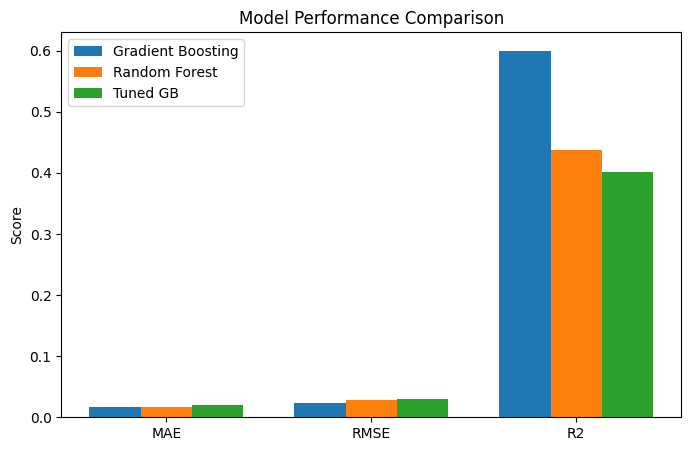

In [ ]:
import matplotlib.pyplot as plt

metrics=["MAE","RMSE","R2"]

gb=[mae,rmse,r2]
rf=[
    mean_absolute_error(y_test,rf_preds),
    mean_squared_error(y_test,rf_preds)**0.5,
    r2_score(y_test,rf_preds)
]
tuned=[best_mae,best_rmse,best_r2]

x=np.arange(len(metrics))
width=0.25

plt.figure(figsize=(8,5))

plt.bar(x-width,gb,width,label="Gradient Boosting")
plt.bar(x,rf,width,label="Random Forest")
plt.bar(x+width,tuned,width,label="Tuned GB")

plt.xticks(x,metrics)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()

plt.show()

In [ ]:
print("="*50)
print("COLD START VALIDATION")
print("="*50)

try:
    recommend(999999)
except ValueError as e:
    print("Cold-start handled successfully.")
    print(e)

COLD START VALIDATION
Cold-start handled successfully.
Unknown item_id: 999999
